# Abbiategrasso: spese comunali per macro-categoria

Estensione del filone finanza comunale, lato uscite.

**Domanda guida:** come si distribuiscono le spese di Abbiategrasso per grandi categorie, e quali voci pesano di più nel profilo recente del Comune?

**Fonte:** mart `siope_uscite_comuni` di DataCivicLab (SIOPE, Banca d'Italia)  
**Dati:** `data/abbiategrasso_finanza_uscite_2021_2025.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('../data/abbiategrasso_finanza_uscite_2021_2025.csv')
df.head()

,comune,anno,macro_categoria,importo_euro,totale_euro,quota_pct
0,Abbiategrasso,2021,Acquisto beni e servizi,12978604.88,25129642.28,51.6
1,Abbiategrasso,2021,Personale,5880149.08,25129642.28,23.4
2,Abbiategrasso,2021,Investimenti,2651953.13,25129642.28,10.6
3,Abbiategrasso,2021,Trasferimenti correnti,2356665.06,25129642.28,9.4
4,Abbiategrasso,2021,Altro,894634.28,25129642.28,3.6


In [2]:
# Ordine categorie per leggibilita'
cat_order = [
    'Acquisto beni e servizi',
    'Personale',
    'Investimenti',
    'Trasferimenti correnti',
    'Tributi e imposte',
    'Altro',
]

abb = df[df['comune'] == 'Abbiategrasso'].copy()
abb['macro_categoria'] = pd.Categorical(abb['macro_categoria'], categories=cat_order, ordered=True)
abb = abb.sort_values(['anno', 'macro_categoria'])

## Composizione uscite Abbiategrasso — 2021 vs 2025

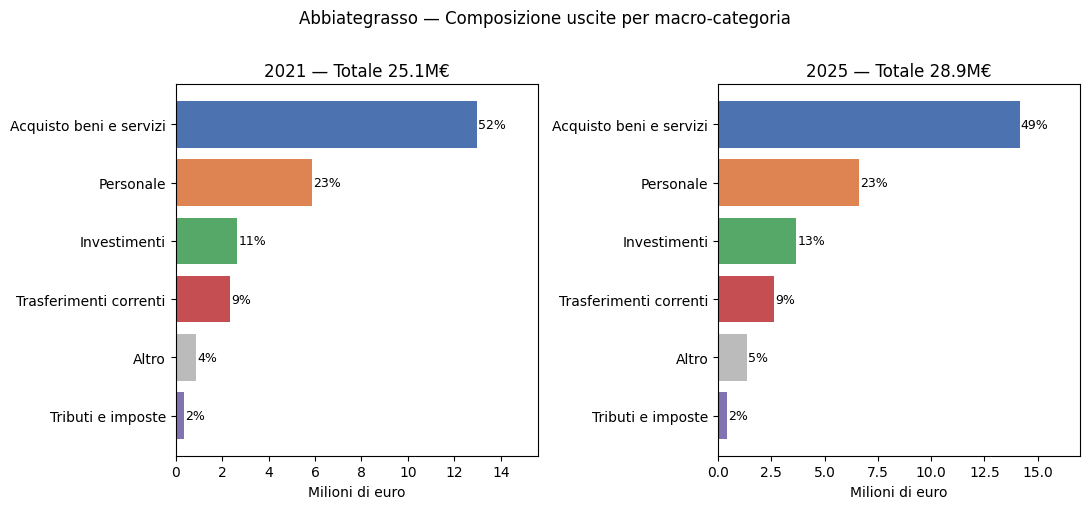

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

colors = {
    'Acquisto beni e servizi': '#4C72B0',
    'Personale': '#DD8452',
    'Investimenti': '#55A868',
    'Trasferimenti correnti': '#C44E52',
    'Tributi e imposte': '#8172B2',
    'Altro': '#BBBBBB',
}

for ax, anno in zip(axes, [2021, 2025]):
    data = abb[abb['anno'] == anno].sort_values('importo_euro', ascending=False)
    totale = data['totale_euro'].iloc[0]
    bar_colors = [colors[c] for c in data['macro_categoria']]
    bars = ax.barh(data['macro_categoria'], data['importo_euro'] / 1e6, color=bar_colors)
    ax.set_xlabel('Milioni di euro')
    ax.set_title(f'{anno} — Totale {totale/1e6:.1f}M€')
    for bar, pct in zip(bars, data['quota_pct']):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{pct:.0f}%', va='center', fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, data['importo_euro'].max() / 1e6 * 1.2)

fig.suptitle('Abbiategrasso — Composizione uscite per macro-categoria', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../figures/abbiategrasso_finanza_uscite_composizione_2021_2025.png', dpi=150, bbox_inches='tight')
plt.show()

## Benchmark 2025 — quota Personale e Acquisto beni e servizi

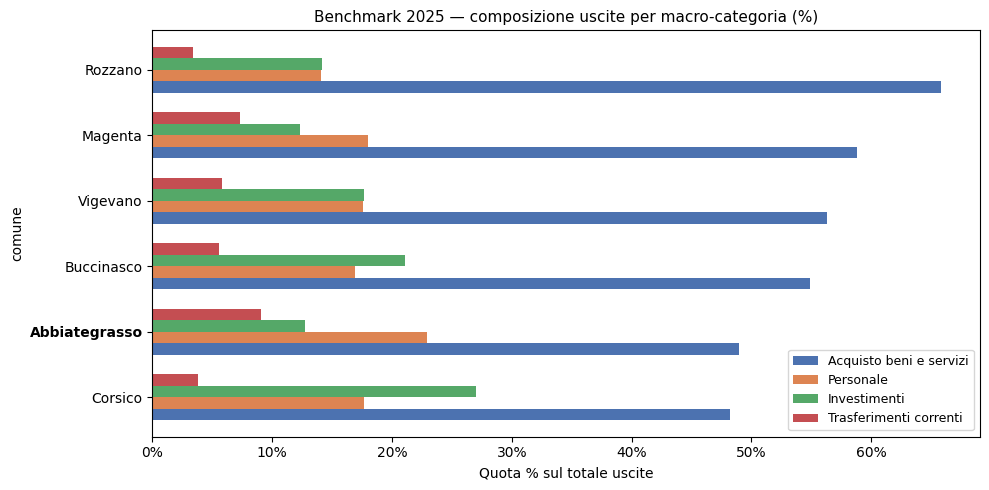

In [4]:
bench_2025 = df[df['anno'] == 2025].copy()

# Pivot per benchmark
pivot = bench_2025.pivot_table(
    index='comune', columns='macro_categoria', values='quota_pct'
).fillna(0)

focus_cols = ['Acquisto beni e servizi', 'Personale', 'Investimenti', 'Trasferimenti correnti']
pivot = pivot[focus_cols].sort_values('Acquisto beni e servizi', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
pivot.plot(kind='barh', ax=ax, color=bar_colors, width=0.7)

ax.set_xlabel('Quota % sul totale uscite')
ax.set_title('Benchmark 2025 — composizione uscite per macro-categoria (%)', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Evidenzia Abbiategrasso
comuni = list(pivot.index)
if 'Abbiategrasso' in comuni:
    idx = comuni.index('Abbiategrasso')
    ax.get_yticklabels()[idx].set_fontweight('bold')

plt.tight_layout()
plt.savefig('../figures/abbiategrasso_finanza_uscite_benchmark_2025.png', dpi=150, bbox_inches='tight')
plt.show()

## Segnali principali

- **Acquisto beni e servizi** è la voce dominante (49% nel 2025), raccogliendo i contratti esternalizzati: rifiuti, mense, asilo nido, assistenza sociale, verde urbano
- **Personale** al 22.9% — la quota più alta tra i sei comuni del benchmark
- **Investimenti** crescono dal 10.6% al 12.7% tra 2021 e 2025
- Il totale uscite cresce del +15% in quattro anni (25.1M → 28.9M€)
- Nel benchmark, Abbiategrasso combina più personale interno e meno esternalizzazione rispetto a Rozzano e Magenta — ma questo non si traduce in minori costi sui singoli servizi (vedi filone rifiuti)